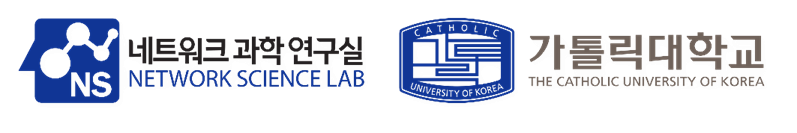

# Community Detection in Graphs

This notebook explores various concepts and algorithms related to community detection in graphs. We will cover:
* **Graph Partitioning:** The fundamental concept of dividing a graph's nodes into disjoint sets.
* **Modularity:** A metric for evaluating the quality of a graph partition.
* **Clique-based Community Detection:** Identifying communities based on cliques.
* **Louvain Method:** A popular greedy optimization method for community detection.
* **Leiden Method:** An improvement over the Louvain method that provides better-connected communities.

We will use `networkx` for graph manipulation and analysis, along with other libraries like `python-louvain`, `cdlib`, and `matplotlib` for community detection and visualization.

# 1. Graph Partitioning

A partition of a graph is a division of its nodes into disjoint sets, where each node belongs to exactly one set. These sets are often referred to as communities or clusters. Let's start by creating a simple graph to illustrate this concept.

In [1]:
# Install necessary libraries for community detection and analysis
!pip install python-louvain community cdlib leidenalg

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 16.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 41.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 83.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 82.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.8 MB/s  0:00:00
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Created wheel for python-louvain: filename=python_louvain-0.16-py3-none-any.whl size=9459 sha256=29fcf2402f2cdd7fbccfd7cb9b0c4

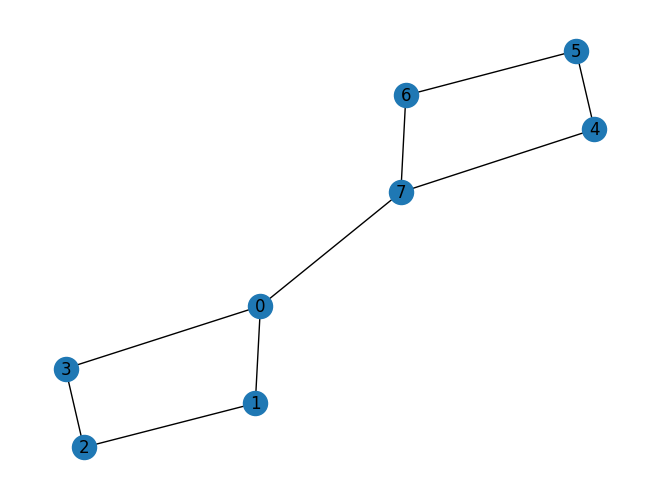

In [2]:
# Import the NetworkX library for graph manipulation
import networkx as nx

# Construct a graph with two cycles connected by an edge
G = nx.Graph()
nx.add_cycle(G, [0, 1, 2, 3])
nx.add_cycle(G, [4, 5, 6, 7])
G.add_edge(0, 7)

# Draw the graph to visualize its structure
nx.draw(G, with_labels=True)

Now, let's define a partition for this graph. A partition is essentially a list of sets, where each set contains the nodes of a community.

In [3]:
# Define a partition of the graph into three communities
partition = [
    {1, 2, 3},
    {4, 5, 6},
    {0, 7},
]

We can verify if our defined `partition` is a valid partition of the graph `G` using a NetworkX helper function.

In [4]:
# Check if the defined partition is a valid partition of the graph
nx.community.is_partition(G, partition)

True

To make it easier to work with partitions, we can create a mapping from each node to its community index.

In [5]:
# Create a dictionary to map each node to its partition index
partition_map = {}
for idx, cluster_nodes in enumerate(partition):
    for node in cluster_nodes:
        partition_map[node] = idx

partition_map

{1: 0, 2: 0, 3: 0, 4: 1, 5: 1, 6: 1, 0: 2, 7: 2}

This mapping allows us to easily check if two nodes belong to the same community.

In [6]:
# Check if nodes 0 and 7 are in the same community
partition_map[0] == partition_map[7]

True

We can also use this mapping to visualize the communities by assigning a different color to each community.

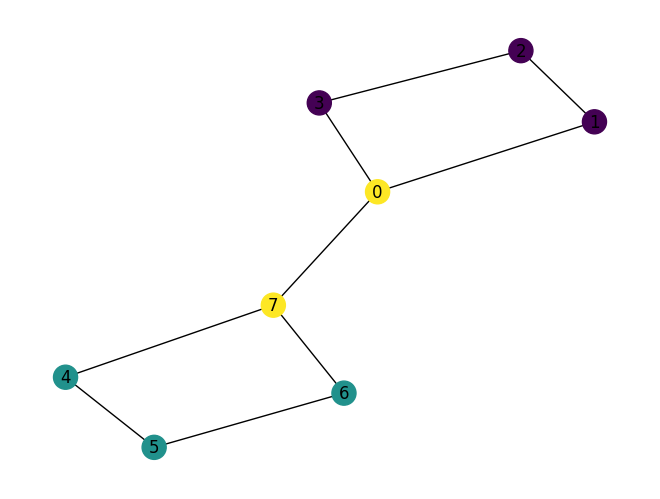

In [7]:
# Color the nodes based on their community assignment
node_colors = [partition_map[n] for n in G.nodes]
        
nx.draw(G, node_color=node_colors, with_labels=True)

# 2. Modularity

Modularity is a measure of the quality of a partition of a graph. It measures the density of links inside communities as compared to links between communities. A higher modularity score indicates a better partition.

The formula for modularity is:

$$Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

where:
- $m$ is the number of edges in the graph.
- $A_{ij}$ is the weight of the edge between nodes $i$ and $j$.
- $k_i$ and $k_j$ are the degrees of nodes $i$ and $j$.
- $c_i$ and $c_j$ are the communities of nodes $i$ and $j$.
- $\delta(c_i, c_j)$ is 1 if $c_i = c_j$ and 0 otherwise.

Let's implement a function to calculate modularity and then compare it with the built-in NetworkX function.

In [8]:
# Define a function to calculate the modularity of a partition
def modularity(G, partition):
    W = sum(G.edges[v, w].get('weight', 1) for v, w in G.edges)
    summation = 0
    for cluster_nodes in partition:
        s_c = sum(G.degree(n, weight='weight') for n in cluster_nodes)
        # Use subgraph to count only internal links
        C = G.subgraph(cluster_nodes)
        W_c = sum(C.edges[v, w].get('weight', 1) for v, w in C.edges)
        summation += W_c - s_c ** 2 / (4 * W)
    
    return summation / W

In [9]:
# Calculate the modularity of our initial partition
modularity(G, partition)

0.2222222222222222

Now, let's consider a more intuitive partition that aligns with the two cycles in our graph. We would expect this partition to have a higher modularity score.

In [10]:
# Define a second partition that seems more natural for the graph
partition_2 = [
    {0, 1, 2, 3},
    {4, 5, 6, 7},
]

# Calculate the modularity of the second partition
modularity(G, partition_2)

0.3888888888888889

As expected, the second partition has a higher modularity. Now, let's verify our calculation using the `modularity` function from NetworkX.

In [11]:
# Use the NetworkX built-in function to calculate modularity
nx.community.quality.modularity(G, partition_2)

0.38888888888888884

# 3. Clique-Based Community Detection

A clique is a subset of vertices in a graph where every two distinct vertices are adjacent. Clique-based community detection methods aim to find communities that are dense subgraphs, often by identifying and merging cliques.

Let's start by constructing a graph and finding all of its cliques.

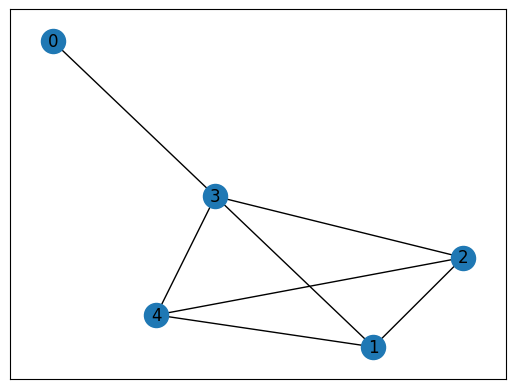

In [12]:
# Create a new graph
G1 = nx.Graph()
edges = [(1, 2), (2, 3), (1, 3), (3, 4), (3, 0), (1, 4), (4, 2)]
G1.add_edges_from(edges)

# Draw the graph
nx.draw_networkx(G1)

Now, we can use `nx.find_cliques()` to find all the cliques in the graph.

In [13]:
# Find all cliques in the graph and sort them by size
cliques = list(nx.find_cliques(G1))
cliques.sort(key=len, reverse=True)
for item in cliques:
    print(item)

[3, 1, 2, 4]
[3, 0]


## K-Clique Communities

The k-clique community detection algorithm finds communities of nodes that can be reached through a series of adjacent k-cliques. Two k-cliques are adjacent if they share k-1 nodes. Let's find the 3-clique communities in a new graph.

[4, 10, 12]

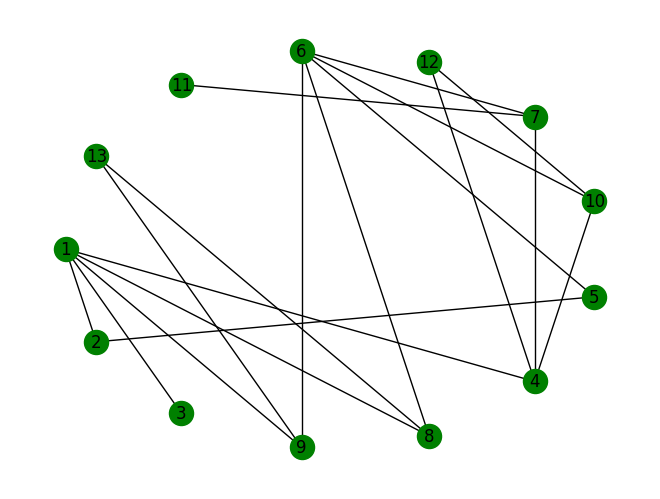

In [14]:
from networkx.algorithms.community import k_clique_communities

# Create a new graph
G_kclique = nx.Graph()
edges = [(1, 2), (1, 3), (1, 9), (1, 8), (1, 4), (2, 5), (4, 10), (4, 7),
         (4, 12), (5, 6), (6, 7), (6, 8), (6, 9), (6, 10), (7, 11), (8, 13), (9, 13), (10, 12)]
G_kclique.add_edges_from(edges)

# Draw the graph
nx.draw(G_kclique, node_color="green", with_labels=True, pos=nx.shell_layout(G_kclique))

# Find 3-clique communities
communities = list(k_clique_communities(G_kclique, 3))
sorted(list(communities[0]))

# 4. Louvain Method

The Louvain method is a popular and efficient algorithm for community detection in large networks. It is a greedy optimization method that attempts to optimize the modularity of a partition of the graph.

Let's start by importing the necessary libraries. We'll use the same graph `G_kclique` from the previous section.

In [15]:
# Import necessary libraries
import matplotlib.pyplot as plt
import community.community_louvain as community_louvain
import networkx.algorithms.community as nx_comm

To visualize the communities, we'll define a helper function to assign a unique color to each community.

In [16]:
# Function to create a list of colors for the nodes based on their community
def create_community_node_colors(graph, communities):
    number_of_colors = len(communities)
    colors = ["#EF9A9A", "#BA68C8", "#64B5F6", "#81C784",
              "#FFF176", "#BDBDBD"][:number_of_colors]
    node_colors = []
    
    # Create a mapping from node to community index
    node_to_community = {}
    for i, community in enumerate(communities):
        for node in community:
            node_to_community[node] = i
            
    # Assign colors to nodes based on their community
    for node in graph.nodes():
        node_colors.append(colors[node_to_community[node]])
        
    return node_colors

The `python-louvain` package returns the partition as a dictionary mapping each node to a community ID. We'll create a helper function to convert this into the list-of-sets format that NetworkX's community functions use.

In [17]:
# Function to get communities from the Louvain algorithm
def get_louvain_communities(graph, random_state=1):
    louvain_partition_dict = community_louvain.best_partition(graph, random_state=random_state)
    unique_partition_labels = list(set(louvain_partition_dict.values()))
    communities = [[] for i in range(len(unique_partition_labels))]
    for node in louvain_partition_dict.keys():
        communities[louvain_partition_dict[node]].append(node)
    return [set(c) for c in communities]

Now, let's apply the Louvain algorithm to our graph.

In [18]:
# Get the communities using the Louvain algorithm
louvain_communities = get_louvain_communities(G_kclique, random_state=1)
louvain_communities

[{1, 2, 3, 5}, {7, 11}, {6, 8, 9, 13}, {4, 10, 12}]

Finally, let's visualize the detected communities and display the modularity score.

In [19]:
# Function to visualize the communities
def visualize_communities(graph, communities, algorithm_name=""):
    node_colors = create_community_node_colors(graph, communities)
    modularity = round(nx_comm.modularity(graph, communities), 6)
    title = f"{algorithm_name} Community Visualization of {len(communities)} communities with modularity of {modularity}"
    pos = nx.spring_layout(graph, k=0.3, iterations=50, seed=2)

    plt.figure(figsize=(10, 6)) 
    nx.draw(graph,
            pos=pos,
            node_size=1000,
            node_color=node_colors,
            with_labels=True,
            font_size=20,
            font_color='black')
    plt.title(title)
    plt.show()

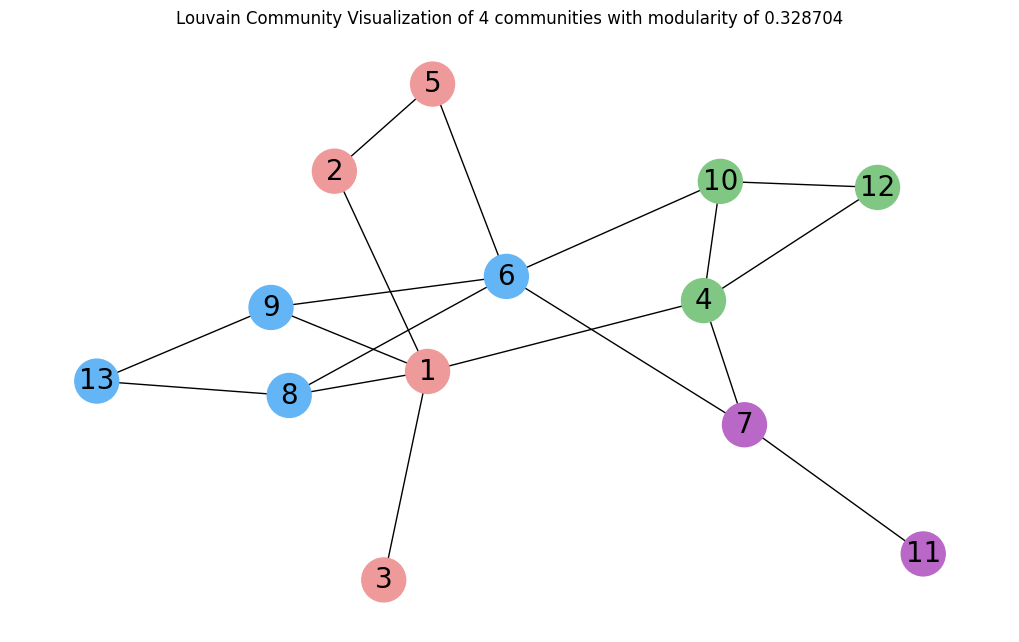

In [20]:
# Visualize the Louvain communities
visualize_communities(G_kclique, louvain_communities, "Louvain")

# 5. Leiden Method

The Leiden algorithm is an improvement over the Louvain algorithm for community detection. It addresses a problem in the Louvain algorithm where communities can be poorly connected. The Leiden algorithm guarantees that communities are well-connected.

We'll use the `cdlib` library to run the Leiden algorithm.

Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer', 'graph_tool', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'infomap', 'wurlitzer'}


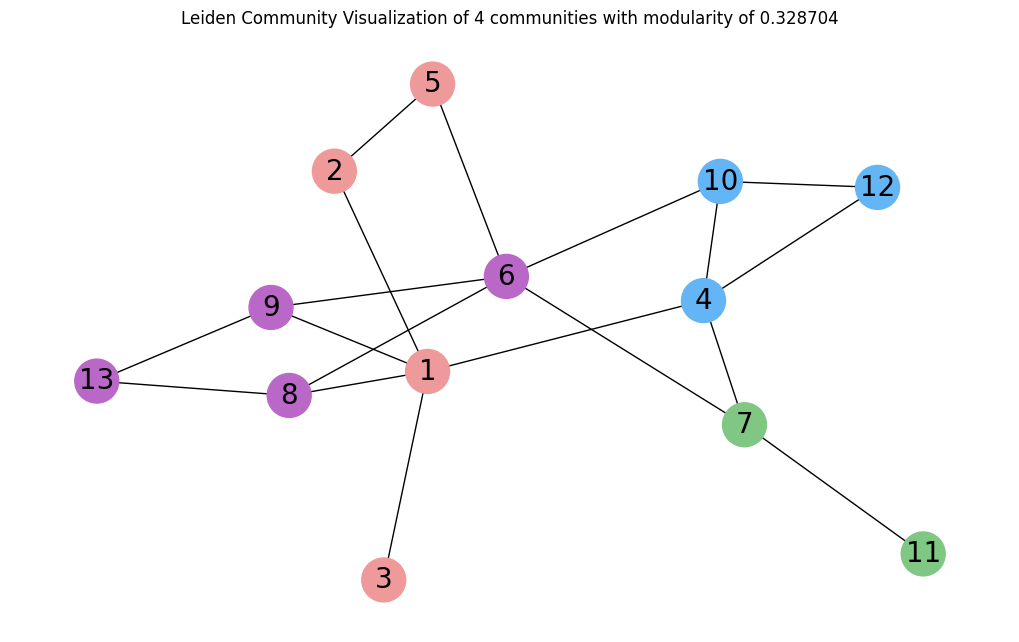

In [21]:
from cdlib.algorithms import leiden

# Get communities using the Leiden algorithm
leiden_communities = leiden(G_kclique).communities

# Visualize the Leiden communities
visualize_communities(G_kclique, leiden_communities, "Leiden")